In [1]:

path = '/home/apolo/Documents/github_projects/ripple_sync/'

scripts_path = path + '/scripts/'
tables_path = path + '/tables/'
figures_path = path + '/figures/'


In [2]:

import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns 
import dabest

import math
import scipy.signal as sig
from scipy import stats as stats

from statsmodels.stats.proportion import proportions_chisquare
import statsmodels.api as sm
import statsmodels.formula.api as smf

%matplotlib widget

import helper_functions as hf

import statsmodels.api as sm
import statsmodels.formula.api as smf


In [3]:
path = '/home/apolo/Documents/github_projects/pcx-1/'

import os

%matplotlib widget
os.chdir(path + '/scripts/')

from pcx1_helper_functions import helper_functions as pcx1_hf, loading_functions as lf, \
    surrogate_functions as surrogate, decoding_model_helper_functions as decode, \
    detect_peaks as dp, wavelet_base_functions as wf, list_manipulation_functions as lmf, \
    waveform_classifier as wave_class, EMDlib as emd, normalization_functions as nf


In [4]:

import warnings

warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

# set the font globally
plt.rcParams.update({'font.family':'sans-serif'})
# set the font name for a font family
plt.rcParams.update({'font.sans-serif':'Arial'})
# when saving svg, keep text as text
plt.rcParams['svg.fonttype'] = 'none' 


In [5]:
sampling_rate = 1250.


In [6]:

os.chdir(tables_path + '/figure_7/')

df = pd.read_csv('Figure_Ripple_Spiking_Coupling.csv')
df = df[df['shank_distance'] != 1400]

# df['shank_distance'] = df['shank_distance'].astype('category')
# Assuming df is your DataFrame and 'shank_distance' is a categorical column
# df['shank_distance'] = df['shank_distance'].cat.remove_categories(1400)
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df['shanks_distance_units'] = df['shank_distance']/200
df = df.reset_index(drop=True)
df


,rat,session,shank_side,shank_distance,neuron_shank,neuron_ID,neuron_type,neuron_to_ripple_side,ripple_shank,mean_vector_length_ripple_epochs,...,number_of_spikes_ripple_epochs,mean_vector_length,mean_vector_length_unbiased,mean_vector_length_zscored,mean_vector_length_pval,firing_rate_outside_ripples,firing_rate_inside_ripples,firing_rate_difference,firing_rate_ratio,shanks_distance_units
0,Ach,Achilles_10252013,left,0.0,0,Achilles_10252013_neuron_102,pyr,ipsi,0,0.329950,...,384,0.342884,0.328201,45.021877,0.0,0.865156,4.516202,3.651046,5.220101,0.0
1,Ach,Achilles_10252013,left,0.0,0,Achilles_10252013_neuron_107,pyr,ipsi,0,0.238628,...,35,0.204645,0.172389,10.479484,0.0,0.178380,0.411633,0.233253,2.307622,0.0
2,Ach,Achilles_10252013,left,0.0,0,Achilles_10252013_neuron_108,pyr,ipsi,0,0.366085,...,260,0.371515,0.354449,39.074789,0.0,0.774117,3.057845,2.283728,3.950107,0.0
3,Ach,Achilles_10252013,left,0.0,0,Achilles_10252013_neuron_110,pyr,ipsi,0,0.496837,...,146,0.491645,0.461112,28.039154,0.0,0.163301,1.717098,1.553796,10.514898,0.0
4,Ach,Achilles_10252013,left,0.0,0,Achilles_10252013_neuron_112,pyr,ipsi,0,0.296566,...,240,0.304663,0.279765,21.003133,0.0,0.251780,2.822626,2.570846,11.210683,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7296,Gat,Gatsby_08282013,right,0.0,6,Gatsby_08282013_neuron_726,int,contra,14,0.052450,...,2550,0.048193,0.042410,12.893987,0.0,7.475653,23.998103,16.522450,3.210168,0.0
7297,Gat,Gatsby_08282013,right,200.0,13,Gatsby_08282013_neuron_1402,int,ipsi,14,0.164941,...,4048,0.030138,0.025449,10.284398,0.0,10.927826,38.095812,27.167986,3.486129,1.0
7298,Gat,Gatsby_08282013,right,200.0,13,Gatsby_08282013_neuron_1403,int,ipsi,14,0.546243,...,6368,0.220510,0.215691,83.662716,0.0,10.525392,59.929380,49.403988,5.693791,1.0
7299,Gat,Gatsby_08282013,right,200.0,13,Gatsby_08282013_neuron_1404,int,ipsi,14,0.175031,...,10356,0.155853,0.151845,67.254974,0.0,24.894514,97.460530,72.566016,3.914940,1.0


In [7]:
ipsi_idx = df.neuron_to_ripple_side == 'ipsi'
neuron_pyr_idx = df.neuron_type == 'pyr'

shank_0_idx = df.shank_distance == 0
shank_200_idx = df.shank_distance == 200
bool_idx = ipsi_idx & (shank_0_idx | shank_200_idx) & neuron_pyr_idx
np.sum(bool_idx)

1407

In [27]:

shank_0_idx = df.shank_distance == 0
shank_200_idx = df.shank_distance == 200

for neuron_type in ['pyr','int']:

    mvl_at_0 = []
    mvl_at_200 = []

    ipsi_idx = df.neuron_to_ripple_side == 'ipsi'
    neuron_type_idx = df.neuron_type == neuron_type
    
    bool_idx = ipsi_idx & (shank_0_idx | shank_200_idx) & neuron_type_idx

    valid_neuron_ids = np.unique(df.neuron_ID[bool_idx])

    for neuron in valid_neuron_ids:
        neuron_id_idx = df.neuron_ID == neuron
        
        mvl_0_aux = np.nanmean(df.mean_vector_length[neuron_id_idx & shank_0_idx & ipsi_idx])
        mvl_200_aux = np.nanmean(df.mean_vector_length[neuron_id_idx & shank_200_idx & ipsi_idx])

        if not np.isnan(mvl_0_aux) and not np.isnan(mvl_200_aux):
            mvl_at_0.append(mvl_0_aux)
            mvl_at_200.append(mvl_200_aux)
        
    mvl_at_0 = np.array(mvl_at_0)
    mvl_at_200 = np.array(mvl_at_200)
    
    # if neuron_type == 'pyr':
    #     mvl_diff_pyr = (mvl_at_0-mvl_at_200)/mvl_at_0
    # else:
    #     mvl_diff_int = (mvl_at_0-mvl_at_200)/mvl_at_0

    if neuron_type == 'pyr':
        mvl_diff_pyr = mvl_at_0-mvl_at_200
    else:
        mvl_diff_int = mvl_at_0-mvl_at_200
    

/tmp/ipykernel_14631/29923990.py:19: RuntimeWarning: Mean of empty slice
  mvl_0_aux = np.nanmean(df.mean_vector_length[neuron_id_idx & shank_0_idx & ipsi_idx])


In [21]:
mvl_diff_int.shape

(115,)

In [28]:
np.nanmean(mvl_diff_pyr)-np.nanmean(mvl_diff_int)

0.15808299449549998

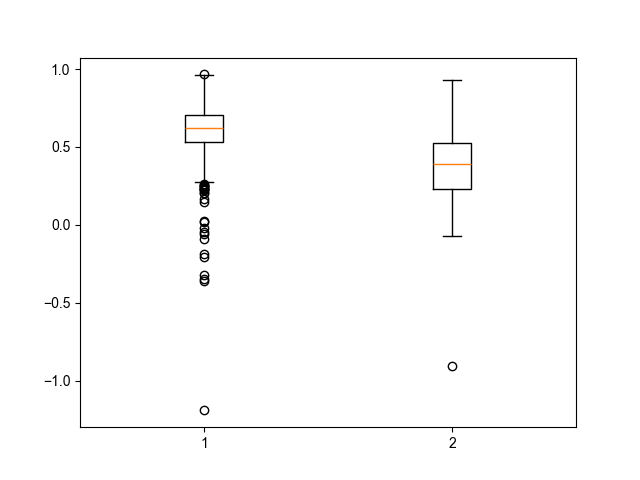

TtestResult(statistic=-10.145057870863152, pvalue=1.5916997496601506e-22, df=639.0)

In [24]:

plt.figure()
plt.boxplot([mvl_diff_pyr,mvl_diff_int])
plt.show()

stats.ttest_ind(mvl_diff_int,mvl_diff_pyr)


In [25]:
np.nanmean(mvl_diff_pyr)

0.5943745219583749

In [26]:
np.nanmean(mvl_diff_int)

0.3793170452377838

In [28]:
np.nanmean(mvl_diff_pyr)-np.nanmean(mvl_diff_int)


0.9080557620709295

In [15]:

df.mean_vector_length[neuron_id_idx & shank_0_idx & ipsi_idx]

7143    0.214436
Name: mean_vector_length, dtype: float64

In [16]:
np.nanmean(df.mean_vector_length[neuron_id_idx & shank_200_idx & ipsi_idx])

0.1273146249152488

In [17]:

custom_palette = sns.light_palette("green", as_cmap=False)
custom_palette = sns.light_palette("green", n_colors=8)


/tmp/ipykernel_14375/2900209645.py:12: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  box = sns.boxplot(data=df_sliced, x='neuron_to_ripple_side', hue="shank_distance", y='mean_vector_length',


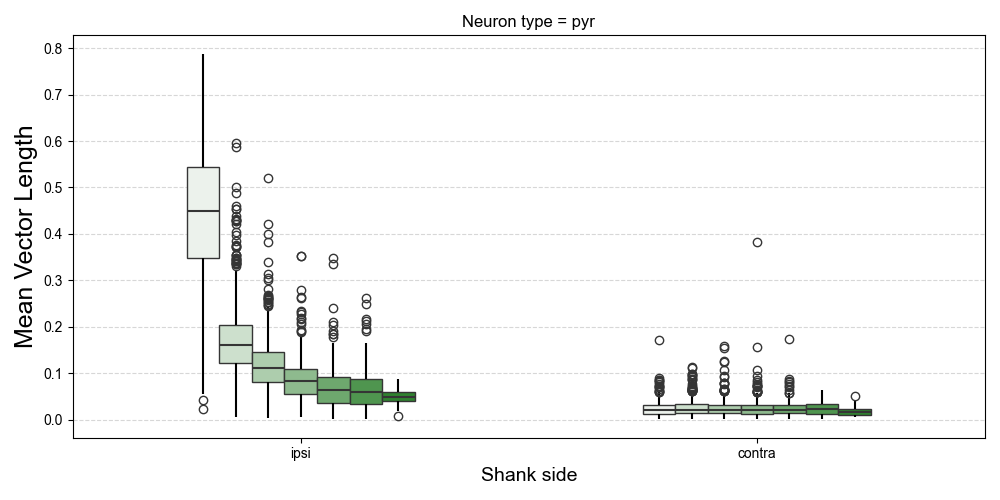

/tmp/ipykernel_14375/2900209645.py:12: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  box = sns.boxplot(data=df_sliced, x='neuron_to_ripple_side', hue="shank_distance", y='mean_vector_length',


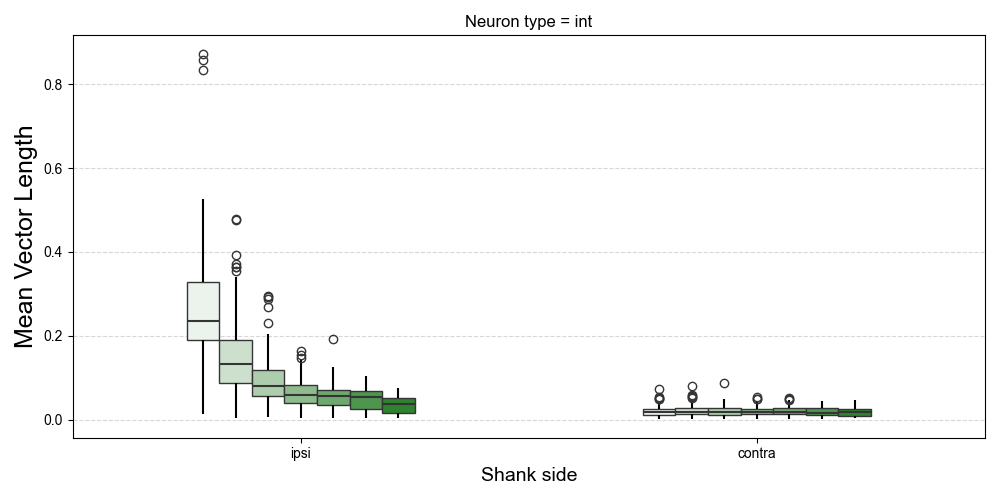

In [18]:
for neuron_type in ['pyr','int']:
    df_sliced = df[df['neuron_type']==neuron_type]
    
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42
    
    # plt.close('all')
    plt.figure(figsize=(10,5))
    
    my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}
    
    box = sns.boxplot(data=df_sliced, x='neuron_to_ripple_side', hue="shank_distance", y='mean_vector_length',
                order=["ipsi", "contra"], showfliers=True, showcaps=False,
                whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
                medianprops=dict(linestyle='-', linewidth=1.5),
                width=0.5,palette=custom_palette)  # Using the custom color palette
    
    plt.ylabel('Mean Vector Length',fontsize=18)
    plt.xlabel('Shank side',fontsize=14)
    plt.grid(linestyle='--',alpha=0.5,axis='y')
    plt.legend([], [], frameon=False)
    plt.title('Neuron type = ' + neuron_type)
    # plt.ylim([0,1])
    
    # we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
    # plt.xticks([0,1],labels=['Left','Right'])
    plt.tight_layout()
    
    
    os.chdir(figures_path + '/figure_7/')
    fig_name = neuron_type + '_mean_vector_length_across_distance.svg'
    # plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
    plt.show()
    # hf.delete_clip_path(fig_name)

